```TCS Stock Price Prediction Using Machine Learning Models```

#### Description:
* In the second part of the project, I used the cleaned and preprocessed TCS stock dataset to build predictive models. The goal was to forecast future stock prices based on historical trends and selected financial indicators.

* Machine learning algorithms were applied to learn patterns from past data and predict future price movements. This phase focused on model building, evaluation, and performance comparison.

### Import Library

In [2]:
# import required library 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [15]:
# Now import clean data which is clean in the previous EDA Analysis
data = pd.read_csv('TCS_cleaned_data.csv')
data.head()

,open,high,low,close,volume,Prev_close,Day_of_Week,Month
0,58.573539,64.131611,58.043755,63.666889,29280,62.783928,4,7
1,64.131619,65.590846,63.202175,64.912354,22272,63.666889,0,7
2,65.999807,67.105848,65.432849,65.683800,48160,64.912354,1,7
3,66.910660,68.778839,66.083452,67.375381,74376,65.683800,2,7
4,68.221162,68.369871,67.338191,67.589142,36024,67.375381,3,7


In [34]:
data.isnull().sum()

open           0
high           0
low            0
close          0
volume         0
Prev_close     0
Day_of_Week    0
Month          0
dtype: int64

### Feature selection

In [35]:
# Extract features for model in the form of x and y 
X = data[['open', 'high', 'low', 'volume', 'Prev_close','Day_of_Week', 'Month']]
y = data['close']

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
sc = StandardScaler()
sc.fit_transform(X) # this give the output in series 

X = pd.DataFrame(sc.fit_transform(X),columns=X.columns)
X.head(5)

,open,high,low,volume,Prev_close,Day_of_Week,Month
0,-1.026926,-1.022263,-1.025241,-1.112625,-1.021990,1.422682,0.138876
1,-1.020224,-1.020521,-1.018954,-1.114760,-1.020924,-1.409650,0.138876
2,-1.017971,-1.018712,-1.016236,-1.106874,-1.019419,-0.701567,0.138876
3,-1.016872,-1.016714,-1.015443,-1.098888,-1.018487,0.006516,0.138876
4,-1.015292,-1.017203,-1.013914,-1.110571,-1.016444,0.714599,0.138876


### Train Test Split 

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
# split the data in to train and test 
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

### Model Apply

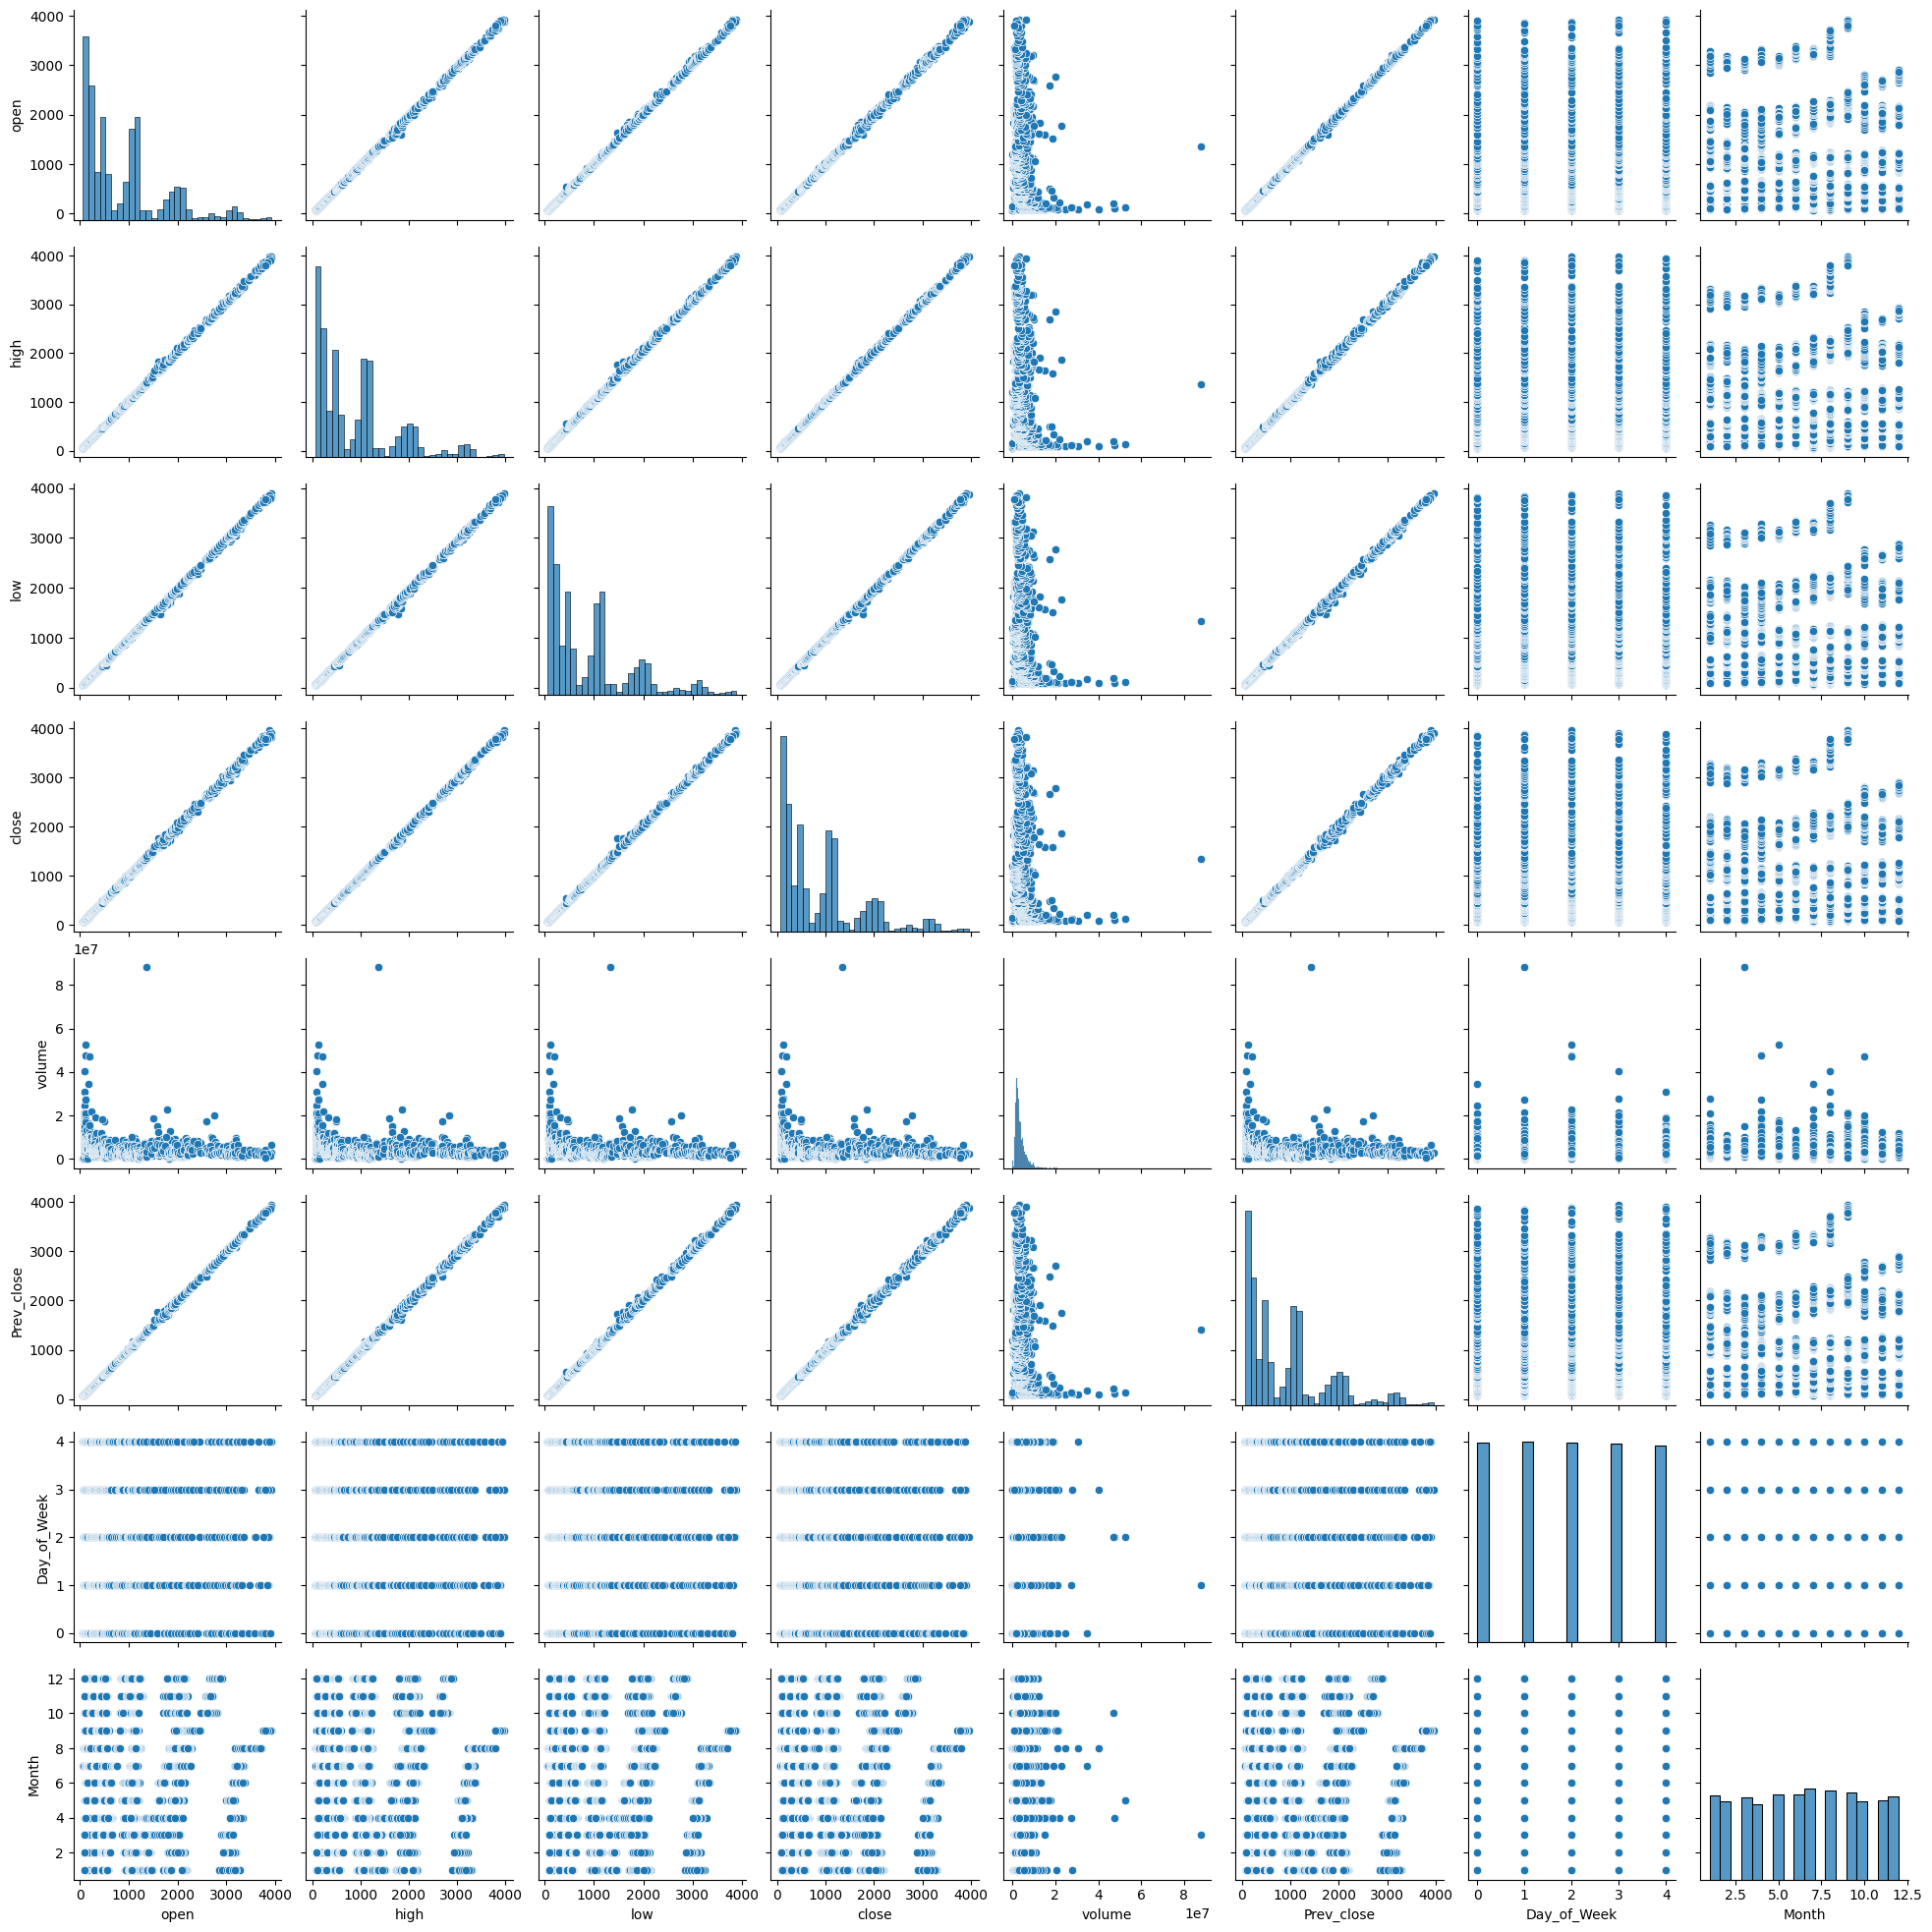

In [40]:
# Now see the behaviour of the graph 
sns.pairplot(data)
plt.show()

In [41]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression

In [43]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)*100 , lr.score(X_train, y_train)*100

(99.99336247097553, 99.99169618771136)

In [47]:
# Predictions
y_pred = lr.predict(X_test)

In [51]:
# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-Squared Score:", r2_score(y_test, y_pred))

Mean Squared Error: 42.14867037878977
R-Squared Score: 0.9999336247097553


In [52]:
# Display actual vs predicted values 
comparison = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': y_pred.flatten()})
comparison.head(10)

,Actual,Predicted
0,1076.373169,1080.583931
1,220.951126,219.803560
2,1196.611084,1201.304830
3,517.383667,516.276874
4,635.896973,632.516488
5,156.912216,156.483886
6,916.317566,919.847643
7,102.401054,102.328895
8,1957.390869,1961.934746
9,472.903259,474.777748


### Visualize Model Performance

* Plot predicted vs. actual values.
* Scatter plot to observe prediction accuracy.

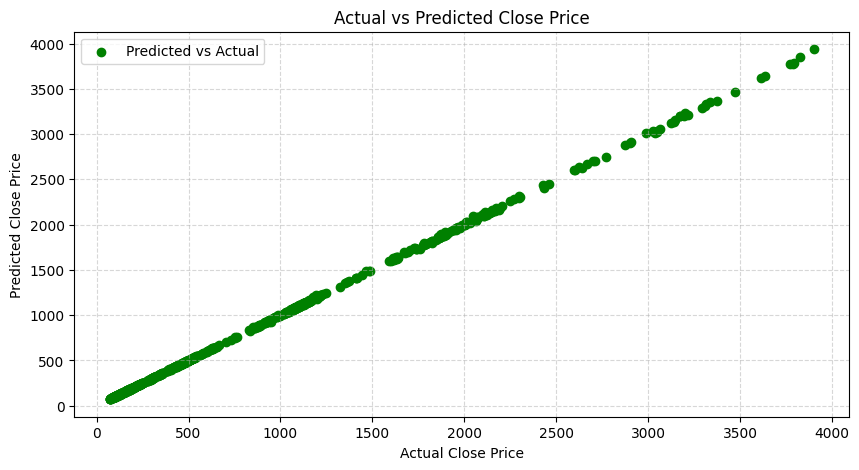

In [56]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='green', label='Predicted vs Actual')

# grid
plt.grid(linestyle = "--" , alpha = 0.5)

# label and title 
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Actual vs Predicted Close Price')
plt.legend()
plt.show()

### Save the Model

In [58]:
import pickle
with open('TCS_Stock_Predictor.pkl', 'wb') as file:
    pickle.dump(lr,file)
print("Model Saved Sucessfully")

Model Saved Sucessfully


```Explanation Summary```
* This project covers EDA, visualization, feature engineering, and prediction modeling for TCS stock prices:
* EDA provides insights into the stock's historical patterns.
* Moving Averages help smooth out price trends.
* Linear Regression is used to predict closing prices.
* Evaluation metrics help validate the model’s accuracy, giving insight into its reliability